# WP4: Bayes factors between the three branch priors on the t0 surveys

The sponsor's model-class comparison, $P(M_i \mid D) \propto P(D \mid M_i)\,P(M_i)$ with $P(D \mid M_i) = \int P(D \mid m, M_i)\,p(m \mid M_i)\,dm$, applied at **district scale** to the three concepts the period prior now contains, each a full five-level sampler on the same Level 1 setting and the same barren piles:

| | Branch | Levels 2 to 4 | Notebook |
|---|---|---|---|
| $M_A$ | Sediment-hosted Cu on the margins of altered basalt piles (Haynes) | piles, reduced facies, ore blankets | `wp4_period_prior_sediment_hosted` |
| $M_B$ | Middleback-type iron (Annex B) | BIF ranges, BIF belt, hematite bodies | `wp4_period_prior_middleback` |
| $M_C$ | Mount Gunson-type stratiform Cu (Annex C) | Woocalla facies on the Pandurra, Cu bodies | `wp4_period_prior_mountgunson` |

Each $p(m \mid M_i)$ is represented by its 10,000-member Sherlock ensemble (seeds 3000 to 12999, identical across branches, so the shared levels are the same realizations). $D$ is the pair of t0 surveys reduced to the ten window statistics of the Section 4 rule (five per survey: anomaly count, median and 90th-percentile peak, median width, residual sd), and $P(D \mid M_i)$ is a synthetic likelihood, a Gaussian fitted to those statistics over the members. The comparison is per district, not per anomaly: the question is which concept the surveys of the whole 16,905 km$^2$ window favour; individual anomalies are the business of the drilling likelihood later.

1. The three hypotheses and what they share
2. What each branch predicts at district scale
3. Bayes factors by synthetic likelihood
4. Check by acceptance ratio under the falsification screen
5. Which statistics would separate the branches
6. What this shows

Run from the `SVOI_OD` folder. Inputs: `08_prior_models/{gen_n10000, middleback/gen_n10000, mountgunson/gen_n10000}/` (`pred_all.npz`, `draws_all.csv`) and `09_sherlock/svoi_core.py`. The window statistics are read from the ensemble-analysis caches (`wp4_ensemble_stats_n10000_<key>.csv`) and computed here when a cache is missing. Figures to `08_prior_models/figures/wp4_BF_*.png`, table to `08_prior_models/wp4_bayes_factor_branches.csv`.

Prior weights: the three branches enter with equal weight, so the posterior odds equal the Bayes factors. The Task 3 placeholder weights (0.40 basalt, 0.15 iron, ...) are weights on *anomaly-source classes*, a different question from the one asked here, and the Mount Gunson branch is not an anomaly source at all.


In [8]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

The three ensembles, their window statistics, and the observed statistics through `svoi_core`. Missing statistic caches are computed with the same sparse-matrix version of `anomaly_stats` the analysis notebooks use (checked against `C.anomaly_stats` on one member).

In [9]:
import sys, io, contextlib, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import sparse, ndimage, stats

sys.path.insert(0, "09_sherlock")
with contextlib.redirect_stdout(io.StringIO()):
    import svoi_core as C
TAB = Path("08_prior_models"); FIG = TAB / "figures"; FIG.mkdir(exist_ok=True)
BR = {"A": dict(name="sediment-hosted Cu (basalt margins)", short="A: basalt margins", gen=TAB / "gen_n10000", col="#2e5e4e", value="Mt_total", vlab="Cu ore (Mt)"),
      "B": dict(name="Middleback-type iron", short="B: Middleback iron", gen=TAB / "middleback/gen_n10000", col="#7a4a1e", value="Fe_Mt_total", vlab="Fe ore (Mt)"),
      "C": dict(name="Mount Gunson-type stratiform Cu", short="C: Mount Gunson Cu", gen=TAB / "mountgunson/gen_n10000", col="#2a78d6", value="Mt_total", vlab="Cu ore (Mt)")}
C_OBS = "#c0504d"
STATS = [("n_per_1e4km2", "Anomalies\nper 10$^4$ km$^2$", False), ("amp_median", "Median\npeak", True), ("amp_p90", "90th-percentile\npeak", True), ("width_median_km", "Median\nwidth (km)", False), ("residual_sd", "Residual\nsd", True)]
KEYS = [f"{f}_{k}" for f in ("g", "m") for k, _, _ in STATS]
LOGSTAT = {k for k in KEYS if k.split("_", 1)[1] in ("amp_median", "amp_p90", "width_median_km", "residual_sd")}
OBS = pd.Series({f"g_{k}": C.OBS_G[k] for k, _, _ in STATS} | {f"m_{k}": C.OBS_M[k] for k, _, _ in STATS})

def grid_weights(tri, GX, GY):
    P = np.c_[GX.ravel(), GY.ravel()]; s = tri.find_simplex(P); ok = s >= 0
    T = tri.transform[s[ok]]; b = np.einsum("nij,nj->ni", T[:, :2], P[ok] - T[:, 2]); bc = np.c_[b, 1 - b.sum(1)]
    W = sparse.csr_matrix((bc.ravel(), (np.repeat(np.flatnonzero(ok), 3), tri.simplices[s[ok]].ravel())), shape=(len(P), tri.npoints))
    return W, ok.reshape(GX.shape)
def plane_projector(x, y):
    A = np.c_[np.ones_like(x), (x - C.X0) / 1e3, (y - C.Y0) / 1e3]; return A, np.linalg.pinv(A)
def stats_batch(V, W, OK, P, T):
    A, Ap = P; R = V.astype(np.float64); R = R - (R @ Ap.T) @ A.T; G = np.asarray((W @ R.T).T).reshape(len(V), *OK.shape); rows = []
    for g, r in zip(G, R):
        lab, n = ndimage.label(OK & (g >= T), structure=np.ones((3, 3)))
        size = ndimage.sum(np.ones_like(g), lab, np.arange(1, n + 1)); keep = size >= C.RULE["min_cells"]
        peak = np.asarray(ndimage.maximum(np.where(OK, g, -np.inf), lab, np.arange(1, n + 1)))[keep]; width = 2 * np.sqrt(size[keep] / np.pi)
        rows.append(dict(n_per_1e4km2=keep.sum() / OK.sum() * 1e4, amp_median=np.median(peak) if len(peak) else np.nan, amp_p90=np.percentile(peak, 90) if len(peak) else np.nan,
                         width_median_km=np.median(width) if len(width) else np.nan, residual_sd=r.std()))
    return rows
WG, OKG = grid_weights(C.TRI_G, C.GX, C.GY); PG_ = plane_projector(C.GXo, C.GYo)
WM, OKM = grid_weights(C.TRI_M, C.GX, C.GY); PM_ = plane_projector(C.MXo, C.MYo)

def load_branch(b):
    gen = b["gen"]; DR = pd.read_csv(gen / "draws_all.csv"); key = hashlib.sha256((gen / "draws_all.csv").read_bytes()).hexdigest()[:10]
    cache = gen / f"wp4_ensemble_stats_n10000_{key}.csv"
    if cache.exists():
        ST = pd.read_csv(cache)
    else:
        t0 = time.time(); z = np.load(gen / "pred_all.npz"); seeds, PG = z["seeds"], z["grav"]; assert (seeds == DR.seed.values).all()
        ref = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, PG[0].astype(float), C.RULE["T_grav_mgal"])[0]; new = stats_batch(PG[:1], WG, OKG, PG_, C.RULE["T_grav_mgal"])[0]
        assert all(np.isclose(ref[k], new[k], equal_nan=True) for k in ref)
        sg = stats_batch(PG, WG, OKG, PG_, C.RULE["T_grav_mgal"]); PM = z["mag"]; sm = []
        for i in range(0, len(seeds), 500): sm += stats_batch(PM[i:i + 500], WM, OKM, PM_, C.RULE["T_mag_nt"])
        del PM, z
        ST = pd.concat([pd.DataFrame({"seed": seeds}), pd.DataFrame(sg).add_prefix("g_"), pd.DataFrame(sm).add_prefix("m_")], axis=1); ST.to_csv(cache, index=False)
        print(f"  {b['short']}: statistics computed in {time.time() - t0:.0f} s and cached")
    assert (ST.seed.values == DR.seed.values).all()
    return DR, ST, key
for k, b in BR.items():
    b["DR"], b["ST"], b["key"] = load_branch(b)
    print(f"{b['short']:22s} {len(b['DR']):>6,} members, seeds {b['DR'].seed.min()}-{b['DR'].seed.max()}, draws key {b['key']}")
N = len(BR["A"]["DR"]); assert all(len(b["DR"]) == N and (b["DR"].seed.values == BR["A"]["DR"].seed.values).all() for b in BR.values())
print("observed statistics: " + ", ".join(f"{k} {v:.3g}" for k, v in OBS.items()))


A: basalt margins      10,000 members, seeds 3000-12999, draws key 1d9870f4c7
B: Middleback iron     10,000 members, seeds 3000-12999, draws key 08838bd281
C: Mount Gunson Cu     10,000 members, seeds 3000-12999, draws key f87b045d8f
observed statistics: g_n_per_1e4km2 1.98, g_amp_median 18.1, g_amp_p90 20.6, g_width_median_km 27.9, g_residual_sd 7.53, m_n_per_1e4km2 9.45, m_amp_median 263, m_amp_p90 2.44e+03, m_width_median_km 7.82, m_residual_sd 440


## Setting

Where the three concepts come from. Olympic Dam and the regional window the sampler fills, and the type localities each concept is drawn from: the Beda/Roopena volcanics outcrop at Roopena for the basalt of concept A, the Middleback Ranges (Iron Knob, Iron Baron, Iron Duke) for concept B, and Mount Gunson (Cattle Grid) for concept C. The coastline and lakes are schematic.

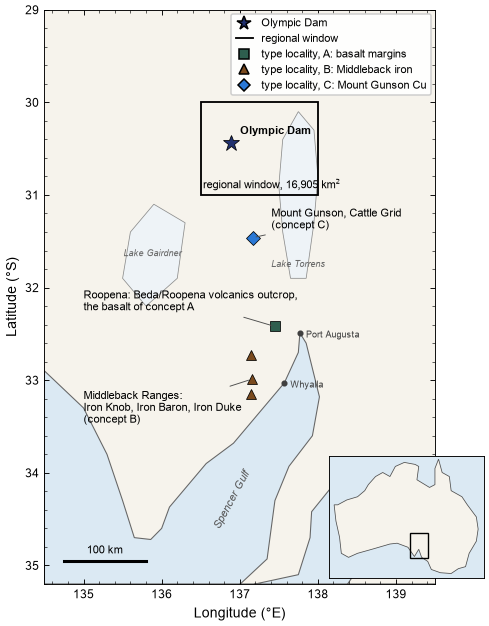

window: lon 136.5 to 138.0, lat -31.0 to -30.0; Olympic Dam to Mount Gunson 116 km, to Iron Knob 255 km, to Roopena 226 km


In [10]:
# ---- location map: the window and the type localities of the three concepts (schematic coastline and lakes, hand-digitised; positions to about 0.05 deg)
from matplotlib.patches import Rectangle, Circle, Polygon
COAST = [(134.5, -32.9), (135.0, -33.3), (135.3, -33.8), (135.5, -34.3), (135.65, -34.7), (135.86, -34.72), (136.0, -34.6), (136.1, -34.37), (136.57, -33.9), (136.92, -33.68),
         (137.2, -33.4), (137.57, -33.03), (137.75, -32.7), (137.77, -32.49), (137.85, -32.6), (138.02, -33.18), (137.93, -33.6), (137.63, -33.93), (137.45, -34.3), (137.35, -34.93),
         (136.88, -35.30), (137.2, -35.2), (137.75, -35.1), (137.9, -34.7), (137.92, -34.42), (138.15, -34.18), (138.5, -34.5), (138.6, -34.93), (138.3, -35.3), (138.1, -35.6), (138.6, -35.7), (139.3, -35.5), (139.5, -35.6)]
LAKES = {"Lake Torrens": [(137.75, -30.1), (137.95, -30.3), (138.0, -30.8), (137.95, -31.3), (137.85, -31.9), (137.65, -31.9), (137.55, -31.4), (137.5, -30.9), (137.55, -30.4)],
         "Lake Gairdner": [(135.9, -31.1), (136.3, -31.3), (136.2, -31.9), (135.8, -32.2), (135.5, -31.9), (135.6, -31.4)]}
AUS = [(113.5, -22), (114, -26), (115, -30), (115.5, -34), (117.5, -35), (120, -34), (124, -33), (129, -31.7), (131, -31.5), (134, -32.5), (135.8, -34.8), (137, -33), (137.8, -35), (139.5, -36), (140.5, -38),
       (143, -38.8), (146, -39), (148, -37.8), (150, -37.3), (151, -34), (153, -31), (153.5, -28), (153, -25), (150.5, -22), (149, -20), (146, -18.5), (145.5, -15), (143.5, -14), (142.5, -10.7),
       (141.5, -13), (141.5, -17), (140, -17.7), (136.5, -15.8), (137, -12.5), (136, -12), (133, -11.5), (130.5, -12.5), (129, -15), (127, -14), (125, -15), (123, -17), (122, -18.5), (120, -20), (117, -20.8), (114.5, -22)]
SITES = {"A": [(137.45, -32.42, "Roopena: Beda/Roopena volcanics outcrop,\nthe basalt of concept A", "s")],
         "B": [(137.15, -32.73, "Iron Knob", "^"), (137.16, -32.99, "Iron Baron", "^"), (137.15, -33.15, "Iron Duke", "^")],
         "C": [(137.17, -31.46, "Mount Gunson (Cattle Grid)", "D")]}
TOWNS = {"Port Augusta": (137.77, -32.49), "Whyalla": (137.57, -33.03)}
SEA, LAND, LAKE = "#dbe9f3", "#f6f3ec", "#eef3f7"
fig, ax = plt.subplots(figsize=(COL15, 5.8)); fig.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)
x0, x1, y0, y1 = 134.5, 139.5, -35.2, -29.0
ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, color=LAND, zorder=0))
ax.add_patch(Polygon(COAST + [(x1, y0), (x0, y0)], closed=True, facecolor=SEA, edgecolor="0.4", lw=0.7, zorder=1))
for name, poly in LAKES.items():
    ax.add_patch(Polygon(poly, closed=True, facecolor=LAKE, edgecolor="0.55", lw=0.5, zorder=1)); cx, cy = np.mean(poly, axis=0); cy = cy - 0.75 if name == "Lake Torrens" else cy; ax.text(cx, cy, name, fontsize=FS_ANNOT - 1, color="0.4", ha="center", va="center", style="italic", zorder=2)
ax.text(136.9, -34.6, "Spencer Gulf", fontsize=FS_ANNOT, color="0.35", style="italic", rotation=62, ha="center")
# the regional window
ax.add_patch(Rectangle((C.WIN.lon_min, C.WIN.lat_min), C.WIN.lon_max - C.WIN.lon_min, C.WIN.lat_max - C.WIN.lat_min, fill=False, edgecolor="k", lw=1.2, zorder=4))
ax.plot(C.OD_LON, C.OD_LAT, marker="*", ms=11, color="#20306f", mec="k", mew=0.5, ls="none", zorder=6)
ax.annotate("Olympic Dam", (C.OD_LON, C.OD_LAT), (6, 6), textcoords="offset points", fontsize=FS_ANNOT, fontweight="bold", zorder=6)
ax.text(C.WIN.lon_min + 0.03, C.WIN.lat_min + 0.04, f"regional window, {C.AREA_KM2:,.0f} km$^2$", fontsize=FS_ANNOT, va="bottom", zorder=6)
for k, b in BR.items():
    for lon, lat, lab, mk in SITES[k]:
        ax.plot(lon, lat, marker=mk, ms=6.5, color=b["col"], mec="k", mew=0.5, ls="none", zorder=6)
ax.annotate(SITES["A"][0][2], (137.45, -32.42), (135.0, -32.15), textcoords="data", fontsize=FS_ANNOT, ha="left", va="center", arrowprops=dict(arrowstyle="-", lw=0.6, color="0.3"), zorder=6)
ax.annotate("Middleback Ranges:\nIron Knob, Iron Baron, Iron Duke\n(concept B)", (137.15, -32.99), (135.0, -33.3), textcoords="data", fontsize=FS_ANNOT, ha="left", va="center", arrowprops=dict(arrowstyle="-", lw=0.6, color="0.3"), zorder=6)
ax.annotate("Mount Gunson, Cattle Grid\n(concept C)", (137.17, -31.46), (12, 6), textcoords="offset points", fontsize=FS_ANNOT, ha="left", arrowprops=dict(arrowstyle="-", lw=0.6, color="0.3"), zorder=6)
for name, (lon, lat) in TOWNS.items():
    ax.plot(lon, lat, "o", ms=3, color="0.25", zorder=5); ax.annotate(name, (lon, lat), (4, -3), textcoords="offset points", fontsize=FS_ANNOT - 1, color="0.25", zorder=5)
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect(1 / np.cos(np.deg2rad(32.5)))
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°S)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{abs(v):.0f}"))
ax.plot([134.75, 134.75 + 100 / 95.8], [-34.95, -34.95], color="k", lw=2, zorder=6); ax.text(134.75 + 50 / 95.8, -34.87, "100 km", ha="center", fontsize=FS_ANNOT)
ax.legend(handles=[plt.Line2D([], [], marker="*", ms=9, color="#20306f", mec="k", ls="none", label="Olympic Dam"), plt.Line2D([], [], color="k", lw=1.2, label="regional window"),
                   ] +
                  [plt.Line2D([], [], marker=SITES[k][0][3], ms=6, color=b["col"], mec="k", ls="none", label=f"type locality, {b['short']}") for k, b in BR.items()],
          loc="upper right", fontsize=FS_ANNOT, frameon=True, framealpha=0.95, edgecolor="0.8")
ins = fig.add_axes([0.665, 0.09, 0.3, 0.19]); ins.add_patch(Polygon(AUS, closed=True, facecolor=LAND, edgecolor="0.3", lw=0.5)); ins.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="k", lw=0.9))
ins.set_xlim(112, 155); ins.set_ylim(-40, -10); ins.set_aspect(1 / np.cos(np.deg2rad(27))); ins.set_xticks([]); ins.set_yticks([]); ins.set_facecolor(SEA)
fig.savefig(FIG / "wp4_BF_00_location_map.png", dpi=300); plt.show()
print(f"window: lon {C.WIN.lon_min} to {C.WIN.lon_max}, lat {C.WIN.lat_min} to {C.WIN.lat_max}; Olympic Dam to Mount Gunson {np.hypot((137.17 - C.OD_LON) * 95.8, (31.46 - 30.441) * 111):.0f} km, to Iron Knob {np.hypot((137.15 - C.OD_LON) * 95.8, (32.73 - 30.441) * 111):.0f} km, to Roopena {np.hypot((137.45 - C.OD_LON) * 95.8, (32.42 - 30.441) * 111):.0f} km")


**Reading the figure.** The window is 147 by 115 km on the Stuart Shelf; all three type localities lie 100 to 260 km south of it on the eastern Gawler Craton and its cover, which is why each concept was admissible in 1975: the rocks were known at surface or in mines, and the question was whether they continue under the Stuart Shelf cover. The inset places the map in Australia.

## Step 1. The three hypotheses and what they share

The branches are run on the same seeds, so Level 1 (cover, basement relief, horsts) and the barren piles are identical member for member; what differs is Levels 2 to 4 of each concept and the basement texture that the branch-specific draws shift in the random stream. This step checks the sharing and lists what each branch adds.

shared columns identical to branch A member for member: B True, C True
shared: L1-1 cover_total_m, L1-2 corr_length_km, L1-3 relief_m, L2-1 intensity_per_1e4km2, L2-3 basalt_multiplier, L5-2 rho_quartzite, L5-2 rho_shale, L5-2 rho_limestone, L5-2 rho_pandurra, L5-2 k_cover, L5-2 res_cover, n_basalt, basalt_frac
A: basalt margins      own rows: L3-1 p_reduced, L3-2 belt_length_km, L4-1 reach_d_km, L4-2 p_ore, L4-3 ore_multiplier
B: Middleback iron     own rows: B3-1 p_belt, B3-2 belt_length_km, B2-1 lens_intensity_per_1e4km2_belt, B2-3 rho_bif, B2-3 k_bif, B2-4 bif_fraction, B4-1 ore_bodies_per_km
C: Mount Gunson Cu     own rows: C3-1 p_reduced, C3-2 belt_length_km, C4-1 reach_km, C4-2 body_intensity_per_1e4km2
basement texture (realized sd) is redrawn per branch: correlation A-B 0.01, A-C 0.01


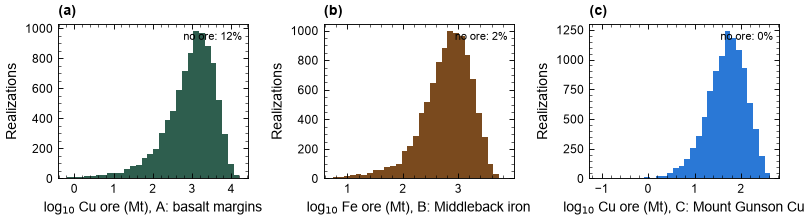

In [11]:
SHARED = [c for c in BR["A"]["DR"].columns if c.startswith(("L1-", "L2-1", "L2-3", "L5-2"))] + ["n_basalt", "basalt_frac"]
same = {k: all(np.allclose(BR["A"]["DR"][c], b["DR"][c]) for c in SHARED) for k, b in BR.items() if k != "A"}
print("shared columns identical to branch A member for member: " + ", ".join(f"{k} {v}" for k, v in same.items()))
print("shared: " + ", ".join(SHARED))
for k, b in BR.items():
    own = [c for c in b["DR"].columns if c not in SHARED and c != "seed" and c[:1] in ("L", "B", "C") and c[1:2].isdigit() and not c.startswith("L5-4")]
    print(f"{b['short']:22s} own rows: " + ", ".join(own))
sd = {k: b["DR"]["basement_sd_realized"].values for k, b in BR.items()}
print(f"basement texture (realized sd) is redrawn per branch: correlation A-B {np.corrcoef(sd['A'], sd['B'])[0, 1]:.2f}, A-C {np.corrcoef(sd['A'], sd['C'])[0, 1]:.2f}")
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.3)); fig.subplots_adjust(left=0.07, right=0.98, top=0.86, bottom=0.25, wspace=0.4)
for ax, (k, b) in zip(axes, BR.items()):
    m = b["DR"][b["value"]].values; ax.hist(np.log10(m[m > 0]), bins=30, color=b["col"]); ax.set_xlabel(f"log$_{{10}}$ {b['vlab']}, {b['short']}"); ax.set_ylabel("Realizations")
    ax.text(0.97, 0.95, f"no ore: {(m <= 0).mean()*100:.0f}%", transform=ax.transAxes, ha="right", va="top", fontsize=FS_ANNOT)
panel_labels(axes, ("(a)", "(b)", "(c)")); fig.savefig(FIG / "wp4_BF_01_branches.png", dpi=300); plt.show()


**Reading the figure.** The ore each concept puts in the window before any data, on a log axis, with the share of realizations that have none. The printed lines confirm that the shared columns are identical across branches and name the rows each branch adds. The basement texture is not shared (its draw sits after the branch rows in the stream), which is why the comparison below is a comparison of ensembles, not of paired members.

## Step 2. What each branch predicts at district scale

The ten window statistics over the 10,000 members of each branch, against the observed survey. Where the three distributions coincide the surveys cannot tell the branches apart; where they differ, the observed value sits at different densities and the Bayes factor registers it.

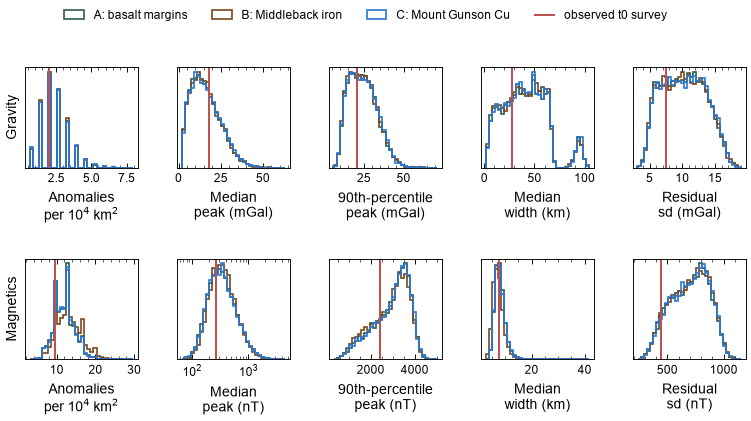

median of each statistic by branch, the observed value, and its quantile under each branch:
                   median A  median B  median C  observed    q A    q B    q C
statistic                                                                     
g_n_per_1e4km2        1.981     1.981     1.981     1.981  0.530  0.523  0.526
g_amp_median         15.145    15.206    15.308    18.059  0.619  0.622  0.609
g_amp_p90            23.862    23.649    23.933    20.613  0.376  0.377  0.373
g_width_median_km    39.961    39.833    39.862    27.869  0.306  0.304  0.300
g_residual_sd        10.245    10.146    10.300     7.527  0.245  0.248  0.239
m_n_per_1e4km2       11.972    13.233    11.972     9.452  0.135  0.083  0.128
m_amp_median        476.795   464.986   472.709   263.288  0.166  0.152  0.166
m_amp_p90          3138.036  3048.968  3152.894  2440.613  0.257  0.292  0.254
m_width_median_km     7.979     7.336     7.979     7.818  0.453  0.601  0.464
m_residual_sd       711.634   713.503  

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.8)); fig.subplots_adjust(left=0.07, right=0.98, top=0.86, bottom=0.16, wspace=0.35, hspace=0.9)
Q = []
for r, f in enumerate(("g", "m")):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r, c]; kk = f"{f}_{key}"; o = OBS[kk]
        allv = np.concatenate([b["ST"][kk].dropna().values for b in BR.values()] + [[o]]); logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        bins = np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 35) if logx else np.linspace(allv.min(), allv.max(), 35)
        for k, b in BR.items():
            v = b["ST"][kk].dropna().values; ax.hist(v, bins=bins, histtype="step", color=b["col"], lw=1.1, density=True, label=b["short"])
            Q.append(dict(statistic=kk, branch=k, median=np.median(v), q_obs=(v < o).mean()))
        if logx: ax.set_xscale("log")
        ax.axvline(o, color=C_OBS, lw=1.3, label="observed t0 survey"); ax.set_xlabel(lab + (f" ({ {'g': 'mGal', 'm': 'nT'}[f] })" if unit else "")); ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator())
axes[0, 0].set_ylabel("Gravity"); axes[1, 0].set_ylabel("Magnetics")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_BF_02_window_statistics.png", dpi=300); plt.show()
Q = pd.DataFrame(Q); T = Q.pivot(index="statistic", columns="branch", values="median").loc[KEYS]; T.columns = [f"median {c}" for c in T.columns]
T["observed"] = OBS[KEYS].values
for k in BR: T[f"q {k}"] = Q[Q.branch == k].set_index("statistic").loc[KEYS, "q_obs"].values
print("median of each statistic by branch, the observed value, and its quantile under each branch:"); print(T.round(3).to_string())


**Reading the figure.** Step histograms are the three branches, the red line the observed survey; the table gives the quantile of the observed value under each. Statistics that depend on the shared setting alone (cover, relief, piles, basement texture) should coincide across the three; the gravity and magnetic peaks and counts are where the BIF ranges of branch B can show, since they are the only branch-specific objects dense and magnetic enough to make an anomaly. Branch C adds nothing the surveys see, so its curves should lie on branch A's up to the basement redraw.

## Step 3. Bayes factors by synthetic likelihood

$P(D \mid M_i)$ is a multivariate Gaussian fitted to the statistics of the 10,000 members of branch $i$ (the peak, width and sd statistics on a log scale; the Jacobian is the same for every branch at the observed point, so it cancels in the ratio), evaluated at the observed statistics. Pairwise $\log_{10}\mathrm{BF}$ for gravity alone, magnetics alone and both surveys, with a 95% Monte Carlo interval from resampling the members (2,000 bootstraps), and the posterior probabilities of the three branches under equal prior weights.

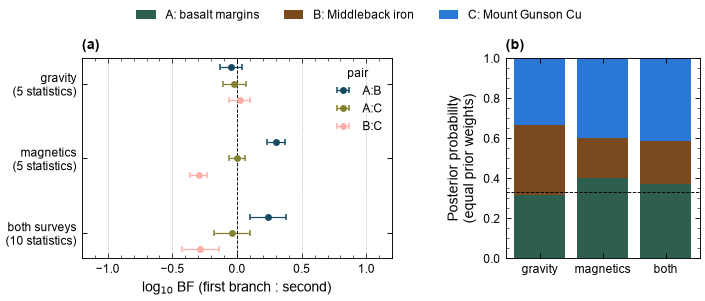

                  statistics pair  log10_BF  ci_lo  ci_hi    BF
      gravity (5 statistics)  A:B    -0.044 -0.128  0.040 0.904
      gravity (5 statistics)  A:C    -0.021 -0.111  0.067 0.953
      gravity (5 statistics)  B:C     0.023 -0.065  0.103 1.054
    magnetics (5 statistics)  A:B     0.300  0.230  0.369 1.994
    magnetics (5 statistics)  A:C     0.002 -0.065  0.062 1.005
    magnetics (5 statistics)  B:C    -0.297 -0.365 -0.233 0.504
both surveys (10 statistics)  A:B     0.243  0.103  0.378 1.751
both surveys (10 statistics)  A:C    -0.042 -0.181  0.098 0.907
both surveys (10 statistics)  B:C    -0.286 -0.426 -0.141 0.518

posterior probability under equal prior weights (A, B, C): gravity (5 statistics): 0.32, 0.35, 0.33; magnetics (5 statistics): 0.40, 0.20, 0.40; both surveys (10 statistics): 0.37, 0.21, 0.41


In [13]:
def X_of(b, keys):
    X = b["ST"][keys].values.astype(float).copy()
    for j, k in enumerate(keys):
        if k in LOGSTAT: X[:, j] = np.log(X[:, j])
    return X[np.isfinite(X).all(1)]
def x_obs(keys): return np.array([np.log(OBS[k]) if k in LOGSTAT else OBS[k] for k in keys])
def synth_loglik(X, x):
    mu = X.mean(0); cov = np.cov(X.T) + 1e-9 * np.eye(X.shape[1]); return stats.multivariate_normal(mu, cov, allow_singular=True).logpdf(x)
SETS = {"gravity (5 statistics)": [k for k in KEYS if k[0] == "g"], "magnetics (5 statistics)": [k for k in KEYS if k[0] == "m"], "both surveys (10 statistics)": KEYS}
PAIRS = [("A", "B"), ("A", "C"), ("B", "C")]
rows, POST = [], {}
rng = np.random.default_rng(0); B_BOOT = 2000
for name, keys in SETS.items():
    X = {k: X_of(b, keys) for k, b in BR.items()}; x = x_obs(keys)
    ll = {k: synth_loglik(X[k], x) for k in BR}
    boot = {k: np.array([synth_loglik(X[k][rng.integers(0, len(X[k]), len(X[k]))], x) for _ in range(B_BOOT)]) for k in BR}
    for i, j in PAIRS:
        d = (boot[i] - boot[j]) / np.log(10)
        rows.append(dict(statistics=name, pair=f"{i}:{j}", log10_BF=(ll[i] - ll[j]) / np.log(10), ci_lo=np.percentile(d, 2.5), ci_hi=np.percentile(d, 97.5)))
    l = np.array([ll[k] for k in BR]); p = np.exp(l - l.max()); POST[name] = p / p.sum()
BF = pd.DataFrame(rows); BF["BF"] = 10 ** BF.log10_BF; BF.to_csv(TAB / "wp4_bayes_factor_branches.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), gridspec_kw=dict(width_ratios=[1.6, 1])); fig.subplots_adjust(left=0.2, right=0.98, top=0.84, bottom=0.19, wspace=0.45)
ax = axes[0]; y = 0; yt, yl = [], []
for name in SETS:
    sub = BF[BF.statistics == name]
    for (_, r), off in zip(sub.iterrows(), (-0.22, 0, 0.22)):
        ax.errorbar(r.log10_BF, y + off, xerr=[[r.log10_BF - r.ci_lo], [r.ci_hi - r.log10_BF]], fmt="o", color=BATLOW({"A:B": 0.15, "A:C": 0.5, "B:C": 0.85}[r.pair]), ms=3.5, capsize=2, lw=0.8, label=r.pair if name == list(SETS)[0] else None)
    yt.append(y); yl.append(name.replace(" (", "\n(")); y += 1
ax.axvline(0, color="k", lw=0.6, ls="--")
for x_ in (-1, -0.5, 0.5, 1): ax.axvline(x_, color="0.6", lw=0.5, ls=":")
ax.set_yticks(yt); ax.set_yticklabels(yl); ax.invert_yaxis(); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_xlabel("log$_{10}$ BF (first branch : second)")
lim = max(1.2, np.abs(BF[["ci_lo", "ci_hi"]].values).max() * 1.1); ax.set_xlim(-lim, lim); ax.legend(loc="upper right", title="pair", ncol=1)
ax = axes[1]; xs = np.arange(len(SETS)); bottom = np.zeros(len(SETS))
for k, b in BR.items():
    v = np.array([POST[n][list(BR).index(k)] for n in SETS]); ax.bar(xs, v, bottom=bottom, color=b["col"], label=b["short"]); bottom += v
ax.axhline(1 / 3, color="k", lw=0.6, ls="--"); ax.set_xticks(xs); ax.set_xticklabels(["gravity", "magnetics", "both"]); ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(0, 1); ax.set_ylabel("Posterior probability\n(equal prior weights)")
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", ncol=3, bbox_to_anchor=(0.55, 1.03))
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_BF_03_bayes_factors.png", dpi=300); plt.show()
print(BF.round(3).to_string(index=False)); print()
print("posterior probability under equal prior weights (A, B, C): " + "; ".join(f"{n}: " + ", ".join(f"{p:.2f}" for p in POST[n]) for n in SETS))


**Reading the figure.** (a) Each point is the log$_{10}$ Bayes factor for one pair of branches and one statistic set, with its 95% bootstrap interval; positive favours the first branch of the pair; the dotted lines at ±0.5 and ±1 are Jeffreys' "substantial" and "strong" marks. (b) The posterior probability of each branch under equal prior weights; the dashed line is 1/3, the prior. A pair whose interval covers zero is a pair the t0 surveys do not separate at district scale.

## Step 4. Check by acceptance ratio under the falsification screen

An estimate of the same Bayes factor that makes no Gaussian assumption: under the member-by-member screen of the analysis notebooks (every $|z_j| < \epsilon$, with the MAD scale now taken over the three ensembles pooled, so the same tolerance applies to all), the ratio of acceptance rates $P(\text{accept} \mid M_i)/P(\text{accept} \mid M_j)$ converges to the Bayes factor as $\epsilon \to 0$ (approximate Bayesian computation). It is shown as a function of $\epsilon$; at the analysis notebooks' $\epsilon$ = 2 it is a coarse check, and at small $\epsilon$ a noisy one.

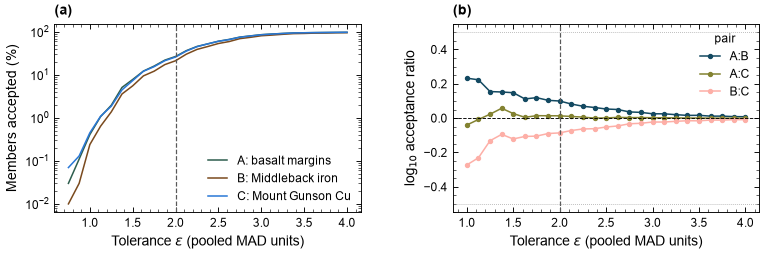

accepted at eps = 2: A 26.8% (2,683), B 21.3% (2,134), C 26.0% (2,603)
log10 acceptance ratio at eps = 2: A:B +0.10, A:C +0.01, B:C -0.09   (synthetic likelihood, both surveys: A:B +0.24, A:C -0.04, B:C -0.29)


In [14]:
POOL = pd.concat([b["ST"][KEYS] for b in BR.values()], ignore_index=True)
def z_of(ST):
    Z = {}
    for k in KEYS:
        s, o, p = ST[k].values.astype(float), OBS[k], POOL[k].values.astype(float)
        if k in LOGSTAT: s, o, p = np.log(s), np.log(o), np.log(p)
        mad = 1.4826 * np.nanmedian(np.abs(p - np.nanmedian(p))); Z[k] = np.where(np.isfinite(s), (s - o) / mad, np.inf)
    return pd.DataFrame(Z)
ZB = {k: z_of(b["ST"]) for k, b in BR.items()}
eps_grid = np.linspace(0.75, 4, 27)
ACC = {k: np.array([(Z.abs() < e).all(axis=1).mean() for e in eps_grid]) for k, Z in ZB.items()}
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.6)); fig.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.2, wspace=0.3)
ax = axes[0]
for k, b in BR.items(): ax.plot(eps_grid, ACC[k] * 100, color=b["col"], label=b["short"])
ax.axvline(2, color="0.35", lw=0.8, ls="--"); ax.set_xlabel("Tolerance $\\epsilon$ (pooled MAD units)"); ax.set_ylabel("Members accepted (%)"); ax.set_yscale("log"); ax.legend(loc="lower right")
ax = axes[1]
for (i, j), v in zip(PAIRS, (0.15, 0.5, 0.85)):
    with np.errstate(divide="ignore", invalid="ignore"): r = np.log10(ACC[i] / ACC[j])
    n_min = np.minimum(ACC[i], ACC[j]) * N; ok = n_min >= 20
    ax.plot(eps_grid[ok], r[ok], "o-", color=BATLOW(v), ms=2.5, label=f"{i}:{j}")
ax.axhline(0, color="k", lw=0.6, ls="--"); ax.axvline(2, color="0.35", lw=0.8, ls="--")
for y_ in (-0.5, 0.5): ax.axhline(y_, color="0.6", lw=0.5, ls=":")
ax.set_xlabel("Tolerance $\\epsilon$ (pooled MAD units)"); ax.set_ylabel("log$_{10}$ acceptance ratio"); ax.legend(loc="upper right", title="pair")
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_BF_04_abc_check.png", dpi=300); plt.show()
i2 = np.argmin(abs(eps_grid - 2))
print("accepted at eps = 2: " + ", ".join(f"{k} {ACC[k][i2]*100:.1f}% ({int(round(ACC[k][i2]*N)):,})" for k in BR))
print("log10 acceptance ratio at eps = 2: " + ", ".join(f"{i}:{j} {np.log10(ACC[i][i2]/ACC[j][i2]):+.2f}" for i, j in PAIRS) + "   (synthetic likelihood, both surveys: " + ", ".join(f"{r.pair} {r.log10_BF:+.2f}" for _, r in BF[BF.statistics == 'both surveys (10 statistics)'].iterrows()) + ")")


**Reading the figure.** (a) The share of each branch's members that pass the screen as the tolerance widens (log axis); the dashed line is the analysis notebooks' $\epsilon$ = 2. (b) The log$_{10}$ ratio of acceptance rates for each pair, plotted only where both branches keep at least 20 members. The two estimates agree when the ratios in (b) near $\epsilon$ = 1 to 2 match the Step 3 values printed below the figure; a ratio that drifts as $\epsilon$ shrinks is the Gaussian fit being tested.

## Step 5. Which statistics would separate the branches

The Bayes factor can be near zero either because the branches predict the same surveys or because they differ in a way the observed value does not pick out. For each statistic: the Kolmogorov-Smirnov distance between the branch pairs (how different the predictions are) and the single-statistic log$_{10}$ Bayes factor (how much the observed value uses that difference).

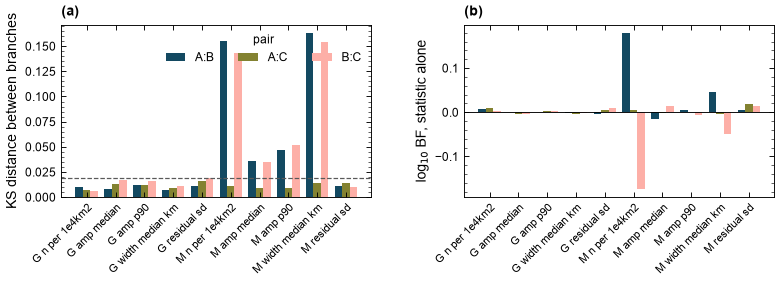

pair               KS A:B  KS A:C  KS B:C  log10BF A:B  log10BF A:C  log10BF B:C
statistic                                                                       
g_n_per_1e4km2      0.010   0.008   0.006         0.01         0.01         0.00
g_amp_median        0.008   0.013   0.017         0.00        -0.00        -0.00
g_amp_p90           0.012   0.012   0.016        -0.00         0.00         0.00
g_width_median_km   0.007   0.009   0.011        -0.00        -0.00        -0.00
g_residual_sd       0.011   0.016   0.019        -0.00         0.01         0.01
m_n_per_1e4km2      0.155   0.011   0.144         0.18         0.01        -0.17
m_amp_median        0.036   0.009   0.035        -0.02        -0.00         0.01
m_amp_p90           0.047   0.009   0.052         0.00        -0.00        -0.01
m_width_median_km   0.163   0.014   0.155         0.05        -0.00        -0.05
m_residual_sd       0.011   0.014   0.010         0.00         0.02         0.01


In [15]:
rows = []
for k in KEYS:
    for i, j in PAIRS:
        a, b = BR[i]["ST"][k].dropna().values, BR[j]["ST"][k].dropna().values
        rows.append(dict(statistic=k, pair=f"{i}:{j}", ks=stats.ks_2samp(a, b).statistic, log10_BF=(synth_loglik(X_of(BR[i], [k]), x_obs([k])) - synth_loglik(X_of(BR[j], [k]), x_obs([k]))) / np.log(10)))
SEP = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8)); fig.subplots_adjust(left=0.08, right=0.98, top=0.86, bottom=0.3, wspace=0.3)
xs = np.arange(len(KEYS)); w = 0.26
for ax, col, lab in [(axes[0], "ks", "KS distance between branches"), (axes[1], "log10_BF", "log$_{10}$ BF, statistic alone")]:
    for (pair, off), v in zip([("A:B", -w), ("A:C", 0), ("B:C", w)], (0.15, 0.5, 0.85)):
        s = SEP[SEP.pair == pair].set_index("statistic").loc[KEYS, col].values; ax.bar(xs + off, s, w, color=BATLOW(v), label=pair)
    ax.set_xticks(xs); ax.set_xticklabels([k.replace("_", " ").replace("g ", "G ").replace("m ", "M ") for k in KEYS], rotation=45, ha="right", rotation_mode="anchor", fontsize=FS_ANNOT); ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylabel(lab)
axes[0].axhline(1.358 * np.sqrt(2 / N), color="0.35", lw=0.8, ls="--"); axes[1].axhline(0, color="k", lw=0.6)
axes[0].legend(loc="upper right", title="pair", ncol=3)
panel_labels(axes, ("(a)", "(b)")); fig.savefig(FIG / "wp4_BF_05_separating_statistics.png", dpi=300); plt.show()
print(SEP.pivot(index="statistic", columns="pair", values="ks").loc[KEYS].round(3).rename(columns=lambda c: f"KS {c}").join(SEP.pivot(index="statistic", columns="pair", values="log10_BF").loc[KEYS].round(2).rename(columns=lambda c: f"log10BF {c}")).to_string())


**Reading the figure.** (a) KS distance between each pair of branches for each statistic (G gravity, M magnetics); the dashed line is the 5% significance level for two samples of 10,000. (b) The Bayes factor each statistic gives on its own. A statistic high in (a) and near zero in (b) is one the branches predict differently but where the observed value falls where the predictions overlap; a statistic high in both is the evidence behind Step 3.

## What this shows

1. The machinery for the sponsor's comparison now runs across concepts rather than within one sampler: three five-level priors on a shared setting, $P(D \mid M_i)$ by synthetic likelihood on the ten window statistics, pairwise Bayes factors with Monte Carlo intervals, an assumption-free check by acceptance ratio, and the statistics behind the result. It runs in seconds once the statistic caches exist.
2. Fill in from the printed outputs after the run: the Bayes factors and intervals (Step 3), the agreement with the acceptance ratios (Step 4), and which statistics carry the difference (Step 5).
3. What the result can and cannot mean. The surveys see Level 1, the piles, Level 5 and, of the branch-specific levels, only the BIF ranges of branch B. A Bayes factor near zero between A and C is therefore expected by construction, not a finding; between B and the others it is a finding about whether the 1969 gravity and 1962 magnetics are consistent with a BIF belt of Middleback character inside the window.
4. The branches are not separated at the anomaly: by the earlier decision, individual anomalies are tested by the drilling likelihood (what each concept predicts a hole to intersect: altered basalt and sulphides at a margin, hematite in BIF, chalcocite on the Pandurra top), with the odds tracked hole by hole from RDD1.

*Next:* the drilling likelihood per branch, the 1975 infill gravity at the members' predicted stations, and the odds trajectory t0 surveys → 1975 infill → RDD1 → RD1..RD10.
